# Geometry analysis for Cs runs

This notebook analyzes the **thickness / geometry** Cs runs using:

- `compton_analysis_outputs/compton_feature_fits_all.csv`
- `peak_analysis_outputs/manual_peak_fits_all.csv`

Changes relative to the previous version:

1. plots now use **error bars**
2. feature positions are analyzed in **keV**, not only ADC
3. the standard-run stability plot no longer crashes on missing day labels
4. the optional window-integration analysis is robust to **sample/background grid mismatch** by interpolating the background onto the sample grid

The central physical split is:

- **behind-source material**: mostly a backscatter / return-scatter question
- **in-front material**: mostly attenuation + spectral reshaping


In [1]:
# -----------------------------
# IMPORTS
# -----------------------------
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 5)


In [2]:
# -----------------------------
# FILE LOCATIONS
# -----------------------------
ROOT = Path("processed_data")
COMPTON_MASTER = Path("compton_analysis_outputs") / "compton_feature_fits_all.csv"
MANUAL_PEAK_FILE = Path("peak_analysis_outputs") / "manual_peak_fits_all.csv"
BACKGROUND_FILE = ROOT / "calibration" / "background_550PM_feb26_213PM_mar3.csv"

def first_existing(*paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return Path(paths[0])

BASE_CAL_FILE = first_existing(
    "calibration_data/base_calibration_feb24.csv",
    "base_calibration_feb24.csv",
    "/mnt/data/base_calibration_feb24.csv",
)

DAILY_ERR_FILE = first_existing(
    "calibration_data/daily_error_adjustments.csv",
    "daily_error_adjustments.csv",
    "/mnt/data/daily_error_adjustments.csv",
)

print("Compton master exists:", COMPTON_MASTER.exists())
print("Manual peak file exists:", MANUAL_PEAK_FILE.exists())
print("Background exists:", BACKGROUND_FILE.exists())
print("Base calibration file:", BASE_CAL_FILE)
print("Daily error file:", DAILY_ERR_FILE)


Compton master exists: True
Manual peak file exists: True
Background exists: True
Base calibration file: calibration_data/base_calibration_feb24.csv
Daily error file: calibration_data/daily_error_adjustments.csv


In [3]:
# -----------------------------
# LOAD TABLES
# -----------------------------
compton_df = pd.read_csv(COMPTON_MASTER)
peak_df = pd.read_csv(MANUAL_PEAK_FILE)
base_cal_df = pd.read_csv(BASE_CAL_FILE)
daily_err_df = pd.read_csv(DAILY_ERR_FILE)

print("Compton rows:", len(compton_df))
print("Peak rows:", len(peak_df))

display(compton_df.head())
display(peak_df.head())


Compton rows: 38
Peak rows: 138


,file,day,preamp,feature_label,center_ADC,center_ADC_err,center_keV,center_keV_err,sigma_ADC,sigma_ADC_err,sigma_keV,sigma_keV_err,amplitude_counts_per_s,amplitude_counts_per_s_err,gaussian_area_counts,gaussian_area_counts_err,fit_xmin,fit_xmax,background_slope,background_slope_err,background_intercept,background_intercept_err,fit_chi2,fit_redchi2,calibration_slope_keV_per_ADC,calibration_slope_err,calibration_offset_keV,calibration_offset_err,calibration_extra_sigma_keV,compton_region_length_ADC,compton_region_length_ADC_err,compton_region_length_keV,compton_region_length_keV_err,compton_region_slope_counts_per_s_per_ADC,compton_region_slope_err_per_ADC,compton_region_slope_counts_per_s_per_keV,compton_region_slope_err_per_keV,compton_region_intercept,compton_region_intercept_err,compton_region_redchi2,compton_region_average_drop_per_ADC,compton_region_average_drop_per_keV,compton_region_average_drop_per_keV_err
0,calibration/daily/Cs_21.9C_preamp0_mar5.csv,mar5,0,backscatter_peak,152.345500,8.495143,196.809441,11.399721,11.411201,12.191034,15.035079,16.062652,3.383306,4.015823,96.774870,154.543275,134.31,181.83,0.019207,0.110334,1.883267,20.771203,0.088948,0.002118,1.317572,0.004624,-3.916731,2.043277,0.000000,181.051508,19.540475,238.548405,25.963023,-0.012667,0.000860,-0.009614,0.000654,7.856350,0.219238,0.072381,-0.012667,-0.009614,0.000654
1,calibration/daily/Cs_21.9C_preamp0_mar5.csv,mar5,0,compton_edge,333.397008,17.597236,435.357846,23.326485,5.537148,21.566336,7.295591,28.415213,0.334910,0.928165,4.648408,22.220366,313.83,352.11,-0.002999,0.032972,5.017046,10.972770,2.081359,0.061216,1.317572,0.004624,-3.916731,2.043277,0.000000,181.051508,19.540475,238.548405,25.963023,-0.012667,0.000860,-0.009614,0.000654,7.856350,0.219238,0.072381,-0.012667,-0.009614,0.000654
2,calibration/daily/Cs_22.0C_preamp0_mar3.csv,mar3,0,backscatter_peak,154.145921,8.569695,199.181625,18.493334,10.640603,17.667129,14.019761,23.277768,2.477301,4.105459,66.074651,155.003545,135.63,173.91,0.016583,0.083251,1.521642,14.026324,0.042297,0.001282,1.317572,0.004624,-3.916731,2.043277,14.485489,181.909142,34.048135,239.678400,49.431056,-0.010736,0.000728,-0.008148,0.000553,6.221884,0.187894,0.069304,-0.010736,-0.008148,0.000553
3,calibration/daily/Cs_22.0C_preamp0_mar3.csv,mar3,0,compton_edge,336.055063,32.952023,438.860025,45.841312,5.398797,51.186167,7.113303,67.441468,0.210314,1.453718,2.846126,33.394145,323.07,349.47,-0.009752,0.073225,6.278416,25.025003,0.026850,0.001279,1.317572,0.004624,-3.916731,2.043277,14.485489,181.909142,34.048135,239.678400,49.431056,-0.010736,0.000728,-0.008148,0.000553,6.221884,0.187894,0.069304,-0.010736,-0.008148,0.000553
4,calibration/daily/Cs_22.4C_preamp0_feb26.csv,feb26,0,backscatter_peak,142.836554,16.339436,184.280719,23.944862,10.236122,33.948154,13.486828,44.729163,4.735009,21.661652,121.491577,686.485213,130.35,159.39,0.078543,0.480526,-0.032053,87.202605,0.032103,0.001338,1.317572,0.004624,-3.916731,2.043277,10.260306,194.855254,86.636145,256.735836,115.116676,-0.021420,0.001209,-0.016257,0.000920,16.343971,0.304485,0.076749,-0.021420,-0.016257,0.000920


,file,group_id,peak_in_group,n_peaks_in_group,theoretical_energy_keV,theoretical_energy_keV_err,clicked_center_ADC,center_ADC,center_ADC_err,sigma_ADC,sigma_ADC_err,amplitude_counts_per_s,amplitude_counts_per_s_err,gaussian_area_counts,fit_xmin,fit_xmax,background_slope,background_intercept
0,calibration/daily/Co60_21.9C_preamp100_mar5.csv,1,1,2,1173.228,0.003,652,649.075865,0.223619,14.749785,0.297055,5.958860,0.087479,220.312327,597,792,-0.005121,3.997337
1,calibration/daily/Co60_21.9C_preamp100_mar5.csv,1,2,2,1332.494,0.002,732,734.205555,0.282125,16.329201,0.369967,5.032531,0.083152,205.987725,597,792,-0.005121,3.997337
2,calibration/daily/Co60_22.4C_preamp100_feb26.csv,1,1,2,1173.228,0.003,652,651.142231,0.184083,14.864290,0.239054,14.550275,0.172824,542.132295,596,815,-0.011299,9.124645
3,calibration/daily/Co60_22.4C_preamp100_feb26.csv,1,2,2,1332.494,0.002,740,737.334233,0.229609,16.270415,0.269837,12.265332,0.158176,500.227869,596,815,-0.011299,9.124645
4,calibration/daily/Co60_22.5C_preamp100_mar3.csv,1,1,2,1173.228,0.003,645,648.684317,0.222826,14.592461,0.292220,4.466219,0.065576,163.364814,596,790,-0.003907,3.043445


In [4]:
# -----------------------------
# CALIBRATION HELPERS
# -----------------------------
def normalize_preamp_value(value):
    text = str(value).lower().replace("_", "").replace(" ", "")
    if "100" in text:
        return 100
    if "0" in text:
        return 0
    try:
        return int(float(value))
    except Exception:
        return np.nan

def extract_day_from_path(relpath):
    lower = str(relpath).lower()
    if "feb_24" in lower or "feb24" in lower:
        return "feb24"
    if "feb_26" in lower or "feb26" in lower:
        return "feb26"
    if "mar_3" in lower or "mar3" in lower:
        return "mar3"
    if "mar_5" in lower or "mar5" in lower:
        return "mar5"
    return None

def extract_preamp_from_path(relpath):
    lower = str(relpath).lower().replace("_", "")
    if "preamp100" in lower:
        return 100
    if "preamp0" in lower:
        return 0
    if "cs" in lower:
        return 0
    return None

base_cal_df["preamp_norm"] = base_cal_df["preamp"].map(normalize_preamp_value)
daily_err_df["preamp_norm"] = daily_err_df["preamp"].map(normalize_preamp_value)

BASE_CAL_MAP = {
    int(row["preamp_norm"]): row
    for _, row in base_cal_df.dropna(subset=["preamp_norm"]).iterrows()
}
DAILY_ERR_MAP = {
    (str(row["day"]).lower(), int(row["preamp_norm"])): row
    for _, row in daily_err_df.dropna(subset=["preamp_norm"]).iterrows()
}

def adc_to_energy(adc, adc_err, relpath):
    adc = np.asarray(adc, dtype=float)
    adc_err = np.asarray(adc_err, dtype=float)

    day = extract_day_from_path(relpath)
    preamp = extract_preamp_from_path(relpath)

    row = BASE_CAL_MAP[preamp]
    slope = float(row["slope"])
    slope_err = float(row["slope_err"])
    offset = float(row["offset"])
    offset_err = float(row["offset_err"])

    energy = slope * adc + offset

    extra_sigma = 0.0
    if day is not None and (day, preamp) in DAILY_ERR_MAP:
        extra_sigma = float(DAILY_ERR_MAP[(day, preamp)]["extra_sigma_keV"])

    energy_err = np.sqrt(
        (slope * adc_err) ** 2 +
        (adc * slope_err) ** 2 +
        offset_err ** 2 +
        extra_sigma ** 2
    )

    return energy, energy_err, slope, slope_err, offset, offset_err, extra_sigma, day, preamp


In [5]:
# -----------------------------
# PARSE GEOMETRY METADATA
# -----------------------------
def _extract_float(pattern, text):
    m = re.search(pattern, str(text))
    if not m:
        return np.nan
    try:
        return float(m.group(1))
    except Exception:
        return np.nan

def parse_geometry_info(relpath):
    rel = Path(relpath).as_posix()
    lower = rel.lower()
    name = Path(rel).name

    if "thickness_effects_behind" in lower:
        geometry_position = "behind"
    elif "thickness_effects_in_front" in lower:
        geometry_position = "in_front"
    else:
        geometry_position = "standard"

    if "/pb" in lower or name.lower().startswith("pb_"):
        material = "Pb"
    elif "/al" in lower or name.lower().startswith("al_"):
        material = "Al"
    else:
        material = "none"

    run_role = "control" if ("control" in lower or "booster" in lower) else "measurement"

    thickness_cm = _extract_float(r"([0-9]+(?:\.[0-9]+)?)cmthick", name)
    pmt_distance_cm = _extract_float(r"([0-9]+(?:\.[0-9]+)?)cmpmt", name)
    source_to_pmt_cm = _extract_float(r"([0-9]+(?:\.[0-9]+)?)cmpmt_tosource", name)

    if np.isnan(source_to_pmt_cm) and geometry_position == "in_front":
        source_to_pmt_cm = pmt_distance_cm

    day = extract_day_from_path(rel)
    preamp = extract_preamp_from_path(rel)

    return {
        "geometry_position": geometry_position,
        "material": material,
        "run_role": run_role,
        "thickness_cm": thickness_cm,
        "pmt_distance_cm": pmt_distance_cm,
        "source_to_pmt_cm": source_to_pmt_cm,
        "day": day,
        "preamp": preamp,
    }

geom_meta = pd.DataFrame([{"file": f, **parse_geometry_info(f)} for f in sorted(set(compton_df["file"]))])
display(geom_meta.head(20))


,file,geometry_position,material,run_role,thickness_cm,pmt_distance_cm,source_to_pmt_cm,day,preamp
0,calibration/daily/Cs_21.9C_preamp0_mar5.csv,standard,none,measurement,NaN,NaN,NaN,mar5,0
1,calibration/daily/Cs_22.0C_preamp0_mar3.csv,standard,none,measurement,NaN,NaN,NaN,mar3,0
2,calibration/daily/Cs_22.4C_preamp0_feb26.csv,standard,none,measurement,NaN,NaN,NaN,feb26,0
3,calibration/feb_24/preamp_0/Cs_22.1C_preamp0_f...,standard,none,measurement,NaN,NaN,NaN,feb24,0
4,cs gain setting/Cs_possible_calcurve_feb_24.csv,standard,none,measurement,NaN,NaN,NaN,feb24,0
5,cs gain setting/Cs_trial_feb_19.csv,standard,none,measurement,NaN,NaN,NaN,None,0
6,data/feb_26/cs137/Cs_22.4C_feb26_run1.csv,standard,none,measurement,NaN,NaN,NaN,feb26,0
7,data/mar_3/cs137/Cs_22.5C_mar3_run1.csv,standard,none,measurement,NaN,NaN,NaN,mar3,0
8,data/mar_5/cs137/Cs_21.9C_mar5_run1.csv,standard,none,measurement,NaN,NaN,NaN,mar5,0
9,data/thickness_effects_behind/Al thickness/Al_...,behind,Al,measurement,1.3,16.0,NaN,None,0


In [6]:
# -----------------------------
# IF NEEDED, AUGMENT COMPTON TABLE WITH KEV COLUMNS
# -----------------------------
if "center_keV" not in compton_df.columns:
    tmp_rows = []
    for _, row in compton_df.iterrows():
        E, Eerr, slope, slope_err, offset, offset_err, extra_sigma, day, preamp = adc_to_energy(
            row["center_ADC"],
            row["center_ADC_err"],
            row["file"],
        )
        sigE = abs(slope) * row["sigma_ADC"]
        sigE_err = np.sqrt((row["sigma_ADC"] * slope_err) ** 2 + (slope * row["sigma_ADC_err"]) ** 2)

        out = row.to_dict()
        out["center_keV"] = float(E)
        out["center_keV_err"] = float(Eerr)
        out["sigma_keV"] = float(sigE)
        out["sigma_keV_err"] = float(sigE_err)
        out["calibration_slope_keV_per_ADC"] = slope
        out["calibration_slope_err"] = slope_err
        out["calibration_offset_keV"] = offset
        out["calibration_offset_err"] = offset_err
        out["calibration_extra_sigma_keV"] = extra_sigma
        if "compton_region_length_keV" not in out and "compton_region_length_ADC" in out:
            out["compton_region_length_keV"] = slope * out["compton_region_length_ADC"]
            out["compton_region_length_keV_err"] = np.sqrt(
                (out["compton_region_length_ADC"] * slope_err) ** 2 +
                (slope * out["compton_region_length_ADC_err"]) ** 2
            )
        if "compton_region_slope_counts_per_s_per_keV" not in out and "compton_region_slope_counts_per_s_per_ADC" in out:
            out["compton_region_slope_counts_per_s_per_keV"] = out["compton_region_slope_counts_per_s_per_ADC"] / slope
            out["compton_region_slope_err_per_keV"] = np.sqrt(
                (out["compton_region_slope_err"] / slope) ** 2 +
                ((out["compton_region_slope_counts_per_s_per_ADC"] * slope_err) / slope ** 2) ** 2
            )
        tmp_rows.append(out)

    compton_df = pd.DataFrame(tmp_rows)


In [7]:
# -----------------------------
# WIDE COMPTON TABLE
# -----------------------------
wide = (
    compton_df
    .pivot_table(
        index="file",
        columns="feature_label",
        values=[
            "center_ADC",
            "center_ADC_err",
            "center_keV",
            "center_keV_err",
            "sigma_ADC",
            "sigma_ADC_err",
            "sigma_keV",
            "sigma_keV_err",
            "amplitude_counts_per_s",
            "amplitude_counts_per_s_err",
            "gaussian_area_counts",
            "gaussian_area_counts_err",
            "fit_redchi2",
            "compton_region_length_ADC",
            "compton_region_length_ADC_err",
            "compton_region_length_keV",
            "compton_region_length_keV_err",
            "compton_region_slope_counts_per_s_per_ADC",
            "compton_region_slope_counts_per_s_per_keV",
            "compton_region_slope_err_per_keV",
            "compton_region_redchi2",
        ],
        aggfunc="first",
    )
)

wide.columns = [f"{a}__{b}" for a, b in wide.columns.to_flat_index()]
wide = wide.reset_index()

geom_df = wide.merge(geom_meta, on="file", how="left")
display(geom_df.head())


,file,amplitude_counts_per_s__backscatter_peak,amplitude_counts_per_s__compton_edge,amplitude_counts_per_s_err__backscatter_peak,amplitude_counts_per_s_err__compton_edge,center_ADC__backscatter_peak,center_ADC__compton_edge,center_ADC_err__backscatter_peak,center_ADC_err__compton_edge,center_keV__backscatter_peak,center_keV__compton_edge,center_keV_err__backscatter_peak,center_keV_err__compton_edge,compton_region_length_ADC__backscatter_peak,compton_region_length_ADC__compton_edge,compton_region_length_ADC_err__backscatter_peak,compton_region_length_ADC_err__compton_edge,compton_region_length_keV__backscatter_peak,compton_region_length_keV__compton_edge,compton_region_length_keV_err__backscatter_peak,compton_region_length_keV_err__compton_edge,compton_region_redchi2__backscatter_peak,compton_region_redchi2__compton_edge,compton_region_slope_counts_per_s_per_ADC__backscatter_peak,compton_region_slope_counts_per_s_per_ADC__compton_edge,compton_region_slope_counts_per_s_per_keV__backscatter_peak,compton_region_slope_counts_per_s_per_keV__compton_edge,compton_region_slope_err_per_keV__backscatter_peak,compton_region_slope_err_per_keV__compton_edge,fit_redchi2__backscatter_peak,fit_redchi2__compton_edge,gaussian_area_counts__backscatter_peak,gaussian_area_counts__compton_edge,gaussian_area_counts_err__backscatter_peak,gaussian_area_counts_err__compton_edge,sigma_ADC__backscatter_peak,sigma_ADC__compton_edge,sigma_ADC_err__backscatter_peak,sigma_ADC_err__compton_edge,sigma_keV__backscatter_peak,sigma_keV__compton_edge,sigma_keV_err__backscatter_peak,sigma_keV_err__compton_edge,geometry_position,material,run_role,thickness_cm,pmt_distance_cm,source_to_pmt_cm,day,preamp
0,calibration/daily/Cs_21.9C_preamp0_mar5.csv,3.383306,0.334910,4.015823,0.928165,152.345500,333.397008,8.495143,17.597236,196.809441,435.357846,11.399721,23.326485,181.051508,181.051508,19.540475,19.540475,238.548405,238.548405,25.963023,25.963023,0.072381,0.072381,-0.012667,-0.012667,-0.009614,-0.009614,0.000654,0.000654,0.002118,0.061216,96.774870,4.648408,154.543275,22.220366,11.411201,5.537148,12.191034,21.566336,15.035079,7.295591,16.062652,28.415213,standard,none,measurement,NaN,NaN,NaN,mar5,0
1,calibration/daily/Cs_22.0C_preamp0_mar3.csv,2.477301,0.210314,4.105459,1.453718,154.145921,336.055063,8.569695,32.952023,199.181625,438.860025,18.493334,45.841312,181.909142,181.909142,34.048135,34.048135,239.678400,239.678400,49.431056,49.431056,0.069304,0.069304,-0.010736,-0.010736,-0.008148,-0.008148,0.000553,0.000553,0.001282,0.001279,66.074651,2.846126,155.003545,33.394145,10.640603,5.398797,17.667129,51.186167,14.019761,7.113303,23.277768,67.441468,standard,none,measurement,NaN,NaN,NaN,mar3,0
2,calibration/daily/Cs_22.4C_preamp0_feb26.csv,4.735009,2.583595,21.661652,37.318277,142.836554,337.691808,16.339436,85.081398,184.280719,441.016555,23.944862,112.598813,194.855254,194.855254,86.636145,86.636145,256.735836,256.735836,115.116676,115.116676,0.076749,0.076749,-0.021420,-0.021420,-0.016257,-0.016257,0.000920,0.000920,0.001338,0.056230,121.491577,90.037334,686.485213,1460.770422,10.236122,13.902990,33.948154,102.714310,13.486828,18.318190,44.729163,135.333519,standard,none,measurement,NaN,NaN,NaN,feb26,0
3,calibration/feb_24/preamp_0/Cs_22.1C_preamp0_f...,4.439946,1.093996,6.841540,4.826343,146.100100,335.619797,9.373680,23.745470,188.580676,438.286531,12.536595,31.391404,189.519697,189.519697,25.528675,25.528675,249.705854,249.705854,33.802166,33.802166,0.077931,0.077931,-0.018490,-0.018490,-0.014033,-0.014033,0.000867,0.000867,0.003209,0.064493,118.107270,23.862107,238.252574,142.644698,10.612287,8.701681,13.816078,35.101554,13.982452,11.465092,18.203744,46.248843,standard,none,measurement,NaN,NaN,NaN,feb24,0
4,cs gain setting/Cs_possible_calcurve_feb_24.csv,4.707809,1.134839,4.196869,5.042641,144.501677,335.390733,5.187995,25.250034,186.474638,437.984722,7.165633,33.367486,190.889056,190.889056,25.777500,25.777500,251.510084,251.510084,34.128220,34.128220,0.0826

In [8]:
# -----------------------------
# PHOTOPEAK TABLE FROM MANUAL PEAK FITS
# -----------------------------
photopeak_df = peak_df.copy()

photopeak_df = photopeak_df[
    np.isfinite(photopeak_df["theoretical_energy_keV"]) &
    np.isclose(photopeak_df["theoretical_energy_keV"], 661.657, atol=5.0)
].copy()

photopeak_df = (
    photopeak_df.sort_values(["file", "amplitude_counts_per_s"], ascending=[True, False])
    .drop_duplicates(subset=["file"])
)

E = []
Eerr = []
sigE = []
sigEerr = []

for _, row in photopeak_df.iterrows():
    e, eerr, slope, slope_err, offset, offset_err, extra_sigma, day, preamp = adc_to_energy(
        row["center_ADC"], row["center_ADC_err"], row["file"]
    )
    E.append(float(e))
    Eerr.append(float(eerr))
    sigE.append(float(abs(slope) * row["sigma_ADC"]))
    sigEerr.append(float(np.sqrt((row["sigma_ADC"] * slope_err) ** 2 + (slope * row["sigma_ADC_err"]) ** 2)))

photopeak_df["photopeak_center_keV"] = E
photopeak_df["photopeak_center_keV_err"] = Eerr
photopeak_df["photopeak_sigma_keV"] = sigE
photopeak_df["photopeak_sigma_keV_err"] = sigEerr

photopeak_df = photopeak_df[[
    "file",
    "center_ADC",
    "center_ADC_err",
    "photopeak_center_keV",
    "photopeak_center_keV_err",
    "sigma_ADC",
    "sigma_ADC_err",
    "photopeak_sigma_keV",
    "photopeak_sigma_keV_err",
    "amplitude_counts_per_s",
    "amplitude_counts_per_s_err",
    "gaussian_area_counts",
]].rename(columns={
    "center_ADC": "photopeak_center_ADC",
    "center_ADC_err": "photopeak_center_ADC_err",
    "sigma_ADC": "photopeak_sigma_ADC",
    "sigma_ADC_err": "photopeak_sigma_ADC_err",
    "amplitude_counts_per_s": "photopeak_amplitude_counts_per_s",
    "amplitude_counts_per_s_err": "photopeak_amplitude_counts_per_s_err",
    "gaussian_area_counts": "photopeak_area_counts",
})

analysis_df = geom_df.merge(photopeak_df, on="file", how="left")
display(analysis_df.head(20))


,file,amplitude_counts_per_s__backscatter_peak,amplitude_counts_per_s__compton_edge,amplitude_counts_per_s_err__backscatter_peak,amplitude_counts_per_s_err__compton_edge,center_ADC__backscatter_peak,center_ADC__compton_edge,center_ADC_err__backscatter_peak,center_ADC_err__compton_edge,center_keV__backscatter_peak,center_keV__compton_edge,center_keV_err__backscatter_peak,center_keV_err__compton_edge,compton_region_length_ADC__backscatter_peak,compton_region_length_ADC__compton_edge,compton_region_length_ADC_err__backscatter_peak,compton_region_length_ADC_err__compton_edge,compton_region_length_keV__backscatter_peak,compton_region_length_keV__compton_edge,compton_region_length_keV_err__backscatter_peak,compton_region_length_keV_err__compton_edge,compton_region_redchi2__backscatter_peak,compton_region_redchi2__compton_edge,compton_region_slope_counts_per_s_per_ADC__backscatter_peak,compton_region_slope_counts_per_s_per_ADC__compton_edge,compton_region_slope_counts_per_s_per_keV__backscatter_peak,compton_region_slope_counts_per_s_per_keV__compton_edge,compton_region_slope_err_per_keV__backscatter_peak,compton_region_slope_err_per_keV__compton_edge,fit_redchi2__backscatter_peak,fit_redchi2__compton_edge,gaussian_area_counts__backscatter_peak,gaussian_area_counts__compton_edge,gaussian_area_counts_err__backscatter_peak,gaussian_area_counts_err__compton_edge,sigma_ADC__backscatter_peak,sigma_ADC__compton_edge,sigma_ADC_err__backscatter_peak,sigma_ADC_err__compton_edge,sigma_keV__backscatter_peak,sigma_keV__compton_edge,sigma_keV_err__backscatter_peak,sigma_keV_err__compton_edge,geometry_position,material,run_role,thickness_cm,pmt_distance_cm,source_to_pmt_cm,day,preamp,photopeak_center_ADC,photopeak_center_ADC_err,photopeak_center_keV,photopeak_center_keV_err,photopeak_sigma_ADC,photopeak_sigma_ADC_err,photopeak_sigma_keV,photopeak_sigma_keV_err,photopeak_amplitude_counts_per_s,photopeak_amplitude_counts_per_s_err,photopeak_area_counts
0,calibration/daily/Cs_21.9C_preamp0_mar5.csv,3.383306,0.334910,4.015823,0.928165,152.345500,333.397008,8.495143,17.597236,196.809441,435.357846,11.399721,23.326485,181.051508,181.051508,19.540475,19.540475,238.548405,238.548405,25.963023,25.963023,0.072381,0.072381,-0.012667,-0.012667,-0.009614,-0.009614,0.000654,0.000654,0.002118,0.061216,96.774870,4.648408,154.543275,22.220366,11.411201,5.537148,12.191034,21.566336,15.035079,7.295591,16.062652,28.415213,standard,none,measurement,NaN,NaN,NaN,mar5,0,505.179638,0.180231,661.693837,3.112571,14.941343,0.204523,19.686296,0.278190,38.228217,0.406552,1431.738174
1,calibration/daily/Cs_22.0C_preamp0_mar3.csv,2.477301,0.210314,4.105459,1.453718,154.145921,336.055063,8.569695,32.952023,199.181625,438.860025,18.493334,45.841312,181.909142,181.909142,34.048135,34.048135,239.678400,239.678400,49.431056,49.431056,0.069304,0.069304,-0.010736,-0.010736,-0.008148,-0.008148,0.000553,0.000553,0.001282,0.001279,66.074651,2.846126,155.003545,33.394145,10.640603,5.398797,17.667129,51.186167,14.019761,7.113303,23.277768,67.441468,standard,none,measurement,NaN,NaN,NaN,mar3,0,505.671076,0.183272,662.341343,14.816546,14.848871,0.208210,19.564457,0.282794,28.570616,0.309751,1063.415433
2,calibration/daily/Cs_22.4C_preamp0_feb26.csv,4.735009,2.583595,21.661652,37.318277,142.836554,337.691808,16.339436,85.081398,184.280719,441.016555,23.944862,112.598813,194.855254,194.855254,86.636145,86.636145,256.735836,256.735836,115.116676,115.116676,0.076749,0.076749,-0.021420,-0.021420,-0.016257,-0.016257,0.000920,0.000920,0.001338,0.056230,121.491577,90.037334,686.485213,1460.770422,10.236122,13.902990,33.948154,102.714310,13.486828,18.318190,44.729163,135.333519,standard,none,measurement,NaN,NaN,NaN,feb26,0,503.121706,0.164891,658.982364,10.719534,15.484003,0.184904,20.401289,0.253927,91.451228,0.857490,3549.463506
3,calibration/feb_24/preamp_0/Cs_22.1C_preamp0_f...,4.439946,1.093996,6.841540,4.826343,146.100100,335.619797,9.373680,23.745470,188.580676,438.286531,12.536595,31.391404,189

In [9]:
# -----------------------------
# DERIVED OBSERVABLES
# -----------------------------
def ratio_err(num, num_err, den, den_err):
    num = np.asarray(num, dtype=float)
    num_err = np.asarray(num_err, dtype=float)
    den = np.asarray(den, dtype=float)
    den_err = np.asarray(den_err, dtype=float)

    out = num / den
    frac = np.sqrt((num_err / num) ** 2 + (den_err / den) ** 2)
    out_err = np.abs(out) * frac
    out_err[~np.isfinite(out_err)] = np.nan
    return out, out_err

analysis_df["backscatter_to_photopeak_area_ratio"], analysis_df["backscatter_to_photopeak_area_ratio_err"] = ratio_err(
    analysis_df["gaussian_area_counts__backscatter_peak"],
    analysis_df["gaussian_area_counts_err__backscatter_peak"],
    analysis_df["photopeak_area_counts"],
    np.sqrt(np.abs(analysis_df["photopeak_area_counts"]))
)

analysis_df["backscatter_to_photopeak_amp_ratio"], analysis_df["backscatter_to_photopeak_amp_ratio_err"] = ratio_err(
    analysis_df["amplitude_counts_per_s__backscatter_peak"],
    analysis_df["amplitude_counts_per_s_err__backscatter_peak"],
    analysis_df["photopeak_amplitude_counts_per_s"],
    analysis_df["photopeak_amplitude_counts_per_s_err"]
)

analysis_df["edge_minus_backscatter_keV"] = (
    analysis_df["center_keV__compton_edge"] -
    analysis_df["center_keV__backscatter_peak"]
)
analysis_df["edge_minus_backscatter_keV_err"] = np.sqrt(
    analysis_df["center_keV_err__compton_edge"] ** 2 +
    analysis_df["center_keV_err__backscatter_peak"] ** 2
)

analysis_df["photopeak_minus_edge_keV"] = (
    analysis_df["photopeak_center_keV"] -
    analysis_df["center_keV__compton_edge"]
)
analysis_df["photopeak_minus_edge_keV_err"] = np.sqrt(
    analysis_df["photopeak_center_keV_err"] ** 2 +
    analysis_df["center_keV_err__compton_edge"] ** 2
)

display(analysis_df[[
    "file",
    "geometry_position",
    "material",
    "thickness_cm",
    "center_keV__backscatter_peak",
    "center_keV__compton_edge",
    "photopeak_center_keV",
    "backscatter_to_photopeak_area_ratio",
    "backscatter_to_photopeak_area_ratio_err",
    "edge_minus_backscatter_keV",
    "edge_minus_backscatter_keV_err",
    "compton_region_slope_counts_per_s_per_keV__backscatter_peak",
]].head(20))


,file,geometry_position,material,thickness_cm,center_keV__backscatter_peak,center_keV__compton_edge,photopeak_center_keV,backscatter_to_photopeak_area_ratio,backscatter_to_photopeak_area_ratio_err,edge_minus_backscatter_keV,edge_minus_backscatter_keV_err,compton_region_slope_counts_per_s_per_keV__backscatter_peak
0,calibration/daily/Cs_21.9C_preamp0_mar5.csv,standard,none,NaN,196.809441,435.357846,661.693837,0.067593,0.107956,238.548405,25.963023,-0.009614
1,calibration/daily/Cs_22.0C_preamp0_mar3.csv,standard,none,NaN,199.181625,438.860025,662.341343,0.062134,0.145773,239.678400,49.431056,-0.008148
2,calibration/daily/Cs_22.4C_preamp0_feb26.csv,standard,none,NaN,184.280719,441.016555,658.982364,0.034228,0.193406,256.735836,115.116676,-0.016257
3,calibration/feb_24/preamp_0/Cs_22.1C_preamp0_f...,standard,none,NaN,188.580676,438.286531,661.715806,0.041764,0.084252,249.705854,33.802166,-0.014033
4,cs gain setting/Cs_possible_calcurve_feb_24.csv,standard,none,NaN,186.474638,437.984722,NaN,NaN,NaN,251.510084,34.128220,-0.014534
5,cs gain setting/Cs_trial_feb_19.csv,standard,none,NaN,148.812316,332.621867,NaN,NaN,NaN,183.809552,10.446648,-0.125172
6,data/feb_26/cs137/Cs_22.4C_feb26_run1.csv,standard,none,NaN,185.851736,435.289575,659.073403,0.027114,0.020696,249.437839,25.583746,-0.016517
7,data/mar_3/cs137/Cs_22.5C_mar3_run1.csv,standard,none,NaN,199.603798,461.742007,661.596694,0.073884,0.087683,262.138209,2201.890503,-0.007432
8,data/mar_5/cs137/Cs_21.9C_mar5_run1.csv,standard,none,NaN,195.781512,463.491952,661.739715,0.062119,0.162273,267.710440,996.160278,-0.008590
9,data/thickness_effects_behind/Al thickness/Al_...,behind,Al,1.3,179.894398,449.578391,651.485549,0.014365,0.012878,269.683992,706.274806,-0.020128


## Suggested analyses to prioritize

1. **Behind runs: backscatter enhancement vs thickness.**  
   Plot backscatter area, backscatter amplitude, and backscatter/photopeak ratio against thickness, split by material.

2. **In-front runs: attenuation and continuum reshaping.**  
   When the 662 keV photopeak becomes unstable, lean on backscatter position, Compton-edge position, Compton-region slope/length, and window-fraction observables.

3. **Matched-thickness comparisons.**  
   Compare behind vs in-front Pb at similar thickness to separate return-scatter enhancement from direct attenuation.

4. **Ordinary Cs stability controls.**  
   Use the ordinary Feb. 26 / Mar. 3 / Mar. 5 Cs runs as stability checks for the electronics and detector.


In [10]:
# -----------------------------
# PLOT HELPERS
# -----------------------------
DAY_ORDER = {"feb24": 0, "feb26": 1, "mar3": 2, "mar5": 3}

def subset_plot_data(df, geometry_position=None, material=None, require_thickness=True):
    out = df.copy()
    if geometry_position is not None:
        out = out[out["geometry_position"] == geometry_position]
    if material is not None:
        out = out[out["material"] == material]
    if require_thickness:
        out = out[np.isfinite(out["thickness_cm"])]
    return out.sort_values("thickness_cm")

def scatter_with_error(ax, df, xcol, ycol, yerrcol=None, xerrcol=None, label=None):
    x = pd.to_numeric(df[xcol], errors="coerce").to_numpy(float)
    y = pd.to_numeric(df[ycol], errors="coerce").to_numpy(float)

    good = np.isfinite(x) & np.isfinite(y)
    if yerrcol is not None and yerrcol in df.columns:
        yerr = pd.to_numeric(df[yerrcol], errors="coerce").to_numpy(float)
    else:
        yerr = None
    if xerrcol is not None and xerrcol in df.columns:
        xerr = pd.to_numeric(df[xerrcol], errors="coerce").to_numpy(float)
    else:
        xerr = None

    if yerr is not None:
        yerr = yerr[good]
    if xerr is not None:
        xerr = xerr[good]

    ax.errorbar(
        x[good], y[good],
        yerr=yerr,
        xerr=xerr,
        fmt="o-",
        capsize=3,
        label=label,
    )

def annotate_points(ax, df, xcol, ycol, label_col="file"):
    for _, row in df.iterrows():
        x = row.get(xcol, np.nan)
        y = row.get(ycol, np.nan)
        if np.isfinite(x) and np.isfinite(y):
            ax.annotate(Path(row[label_col]).stem, (x, y), fontsize=8, alpha=0.8)

def grouped_error_plot(df, xcol, ycol, groupcol, title="", xlabel="", ylabel="", yerrcol=None, xerrcol=None):
    fig, ax = plt.subplots(figsize=(9, 5))
    for key, sub in df.groupby(groupcol):
        sub = sub.sort_values(xcol)
        scatter_with_error(ax, sub, xcol, ycol, yerrcol=yerrcol, xerrcol=xerrcol, label=str(key))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

def day_stability_plot(df, ycols, yerrcols, labels, title, ylabel):
    plot_df = df.copy()
    plot_df["day_order"] = plot_df["day"].map(DAY_ORDER)
    plot_df = plot_df[np.isfinite(plot_df["day_order"])].sort_values("day_order")

    fig, ax = plt.subplots(figsize=(9, 5))
    for ycol, yerrcol, label in zip(ycols, yerrcols, labels):
        scatter_with_error(ax, plot_df, "day_order", ycol, yerrcol=yerrcol, label=label)

    ax.set_xticks(list(DAY_ORDER.values()))
    ax.set_xticklabels(list(DAY_ORDER.keys()))
    ax.set_title(title)
    ax.set_xlabel("Day")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


,file,material,thickness_cm,gaussian_area_counts__backscatter_peak,gaussian_area_counts_err__backscatter_peak,amplitude_counts_per_s__backscatter_peak,amplitude_counts_per_s_err__backscatter_peak,backscatter_to_photopeak_area_ratio,backscatter_to_photopeak_area_ratio_err
12,data/thickness_effects_behind/Pb thickness/Pb_...,Pb,0.1,105.560632,81.988309,4.264296,1.901924,0.019386,0.015059
9,data/thickness_effects_behind/Al thickness/Al_...,Al,1.3,79.543476,71.301975,3.812255,1.930077,0.014365,0.012878
11,data/thickness_effects_behind/Al thickness/Al_...,Al,2.3,121.537202,82.059354,7.301340,2.865254,0.010799,0.007292
15,data/thickness_effects_behind/Pb thickness/Pb_...,Pb,4.8,89.966169,73.647169,3.942786,1.823733,0.016216,0.013277
14,data/thickness_effects_behind/Pb thickness/Pb_...,Pb,7.5,116.140092,79.514161,4.332459,1.684343,0.021388,0.014646
13,data/thickness_effects_behind/Pb thickness/Pb_...,Pb,14.5,126.757993,93.676947,4.527758,1.878522,0.023300,0.017222
10,data/thickness_effects_behind/Al thickness/Al_...,Al,14.7,76.021192,59.904898,4.164348,1.945756,0.013710,0.010805


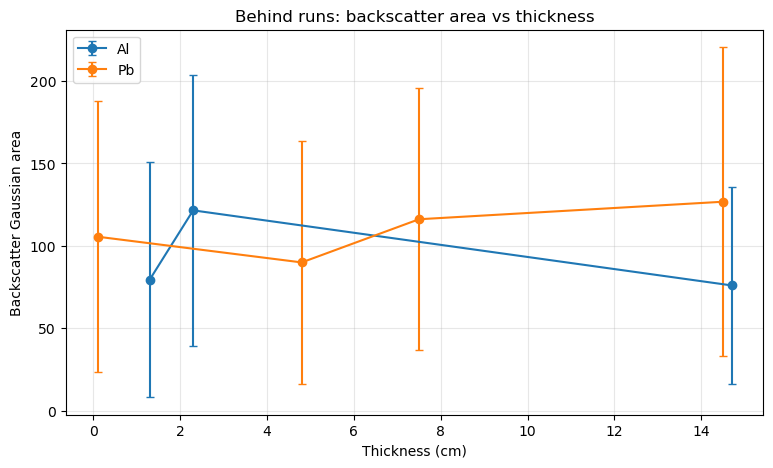

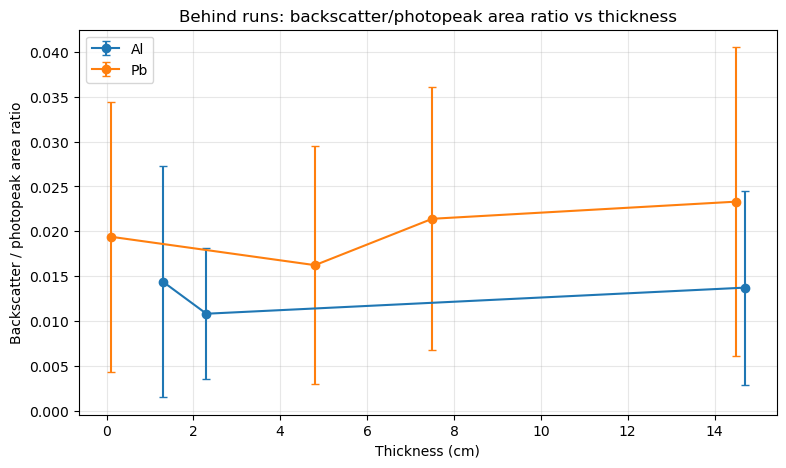

In [11]:
# -----------------------------
# ANALYSIS 1: BEHIND-RUN BACKSCATTER ENHANCEMENT
# -----------------------------
behind_df = subset_plot_data(analysis_df, geometry_position="behind")
display(behind_df[[
    "file",
    "material",
    "thickness_cm",
    "gaussian_area_counts__backscatter_peak",
    "gaussian_area_counts_err__backscatter_peak",
    "amplitude_counts_per_s__backscatter_peak",
    "amplitude_counts_per_s_err__backscatter_peak",
    "backscatter_to_photopeak_area_ratio",
    "backscatter_to_photopeak_area_ratio_err",
]])

grouped_error_plot(
    behind_df,
    xcol="thickness_cm",
    ycol="gaussian_area_counts__backscatter_peak",
    yerrcol="gaussian_area_counts_err__backscatter_peak",
    groupcol="material",
    title="Behind runs: backscatter area vs thickness",
    xlabel="Thickness (cm)",
    ylabel="Backscatter Gaussian area",
)

grouped_error_plot(
    behind_df,
    xcol="thickness_cm",
    ycol="backscatter_to_photopeak_area_ratio",
    yerrcol="backscatter_to_photopeak_area_ratio_err",
    groupcol="material",
    title="Behind runs: backscatter/photopeak area ratio vs thickness",
    xlabel="Thickness (cm)",
    ylabel="Backscatter / photopeak area ratio",
)


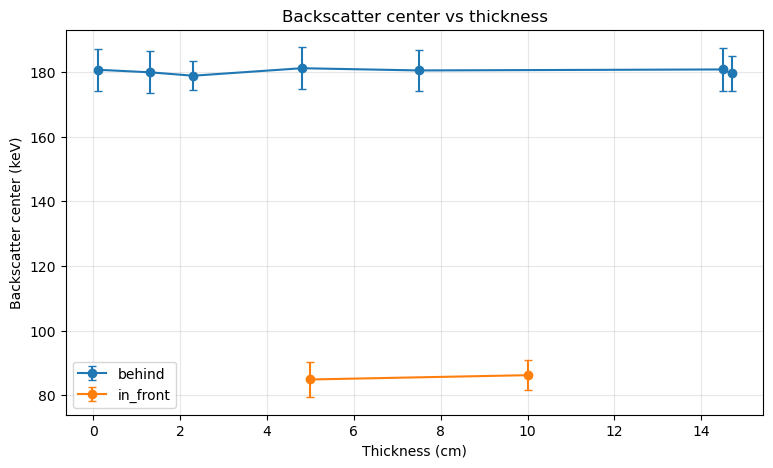

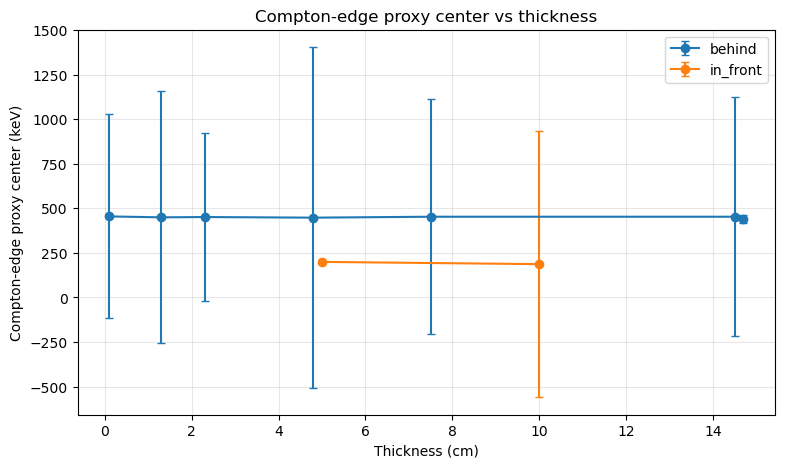

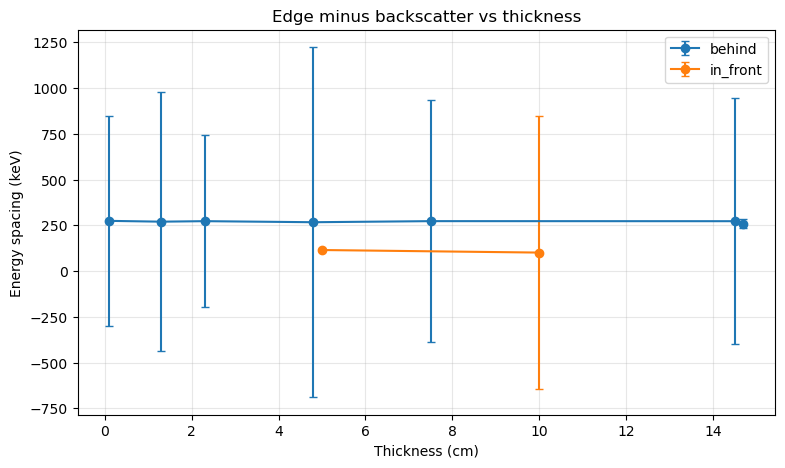

In [12]:
# -----------------------------
# ANALYSIS 2: FEATURE POSITION SHIFTS (ENERGY)
# -----------------------------
thickness_df = analysis_df[analysis_df["geometry_position"].isin(["behind", "in_front"])].copy()

grouped_error_plot(
    thickness_df,
    xcol="thickness_cm",
    ycol="center_keV__backscatter_peak",
    yerrcol="center_keV_err__backscatter_peak",
    groupcol="geometry_position",
    title="Backscatter center vs thickness",
    xlabel="Thickness (cm)",
    ylabel="Backscatter center (keV)",
)

grouped_error_plot(
    thickness_df,
    xcol="thickness_cm",
    ycol="center_keV__compton_edge",
    yerrcol="center_keV_err__compton_edge",
    groupcol="geometry_position",
    title="Compton-edge proxy center vs thickness",
    xlabel="Thickness (cm)",
    ylabel="Compton-edge proxy center (keV)",
)

grouped_error_plot(
    thickness_df,
    xcol="thickness_cm",
    ycol="edge_minus_backscatter_keV",
    yerrcol="edge_minus_backscatter_keV_err",
    groupcol="geometry_position",
    title="Edge minus backscatter vs thickness",
    xlabel="Thickness (cm)",
    ylabel="Energy spacing (keV)",
)


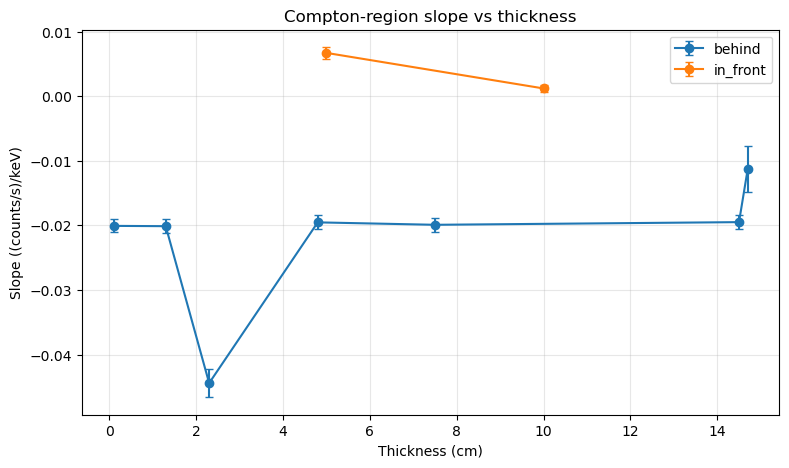

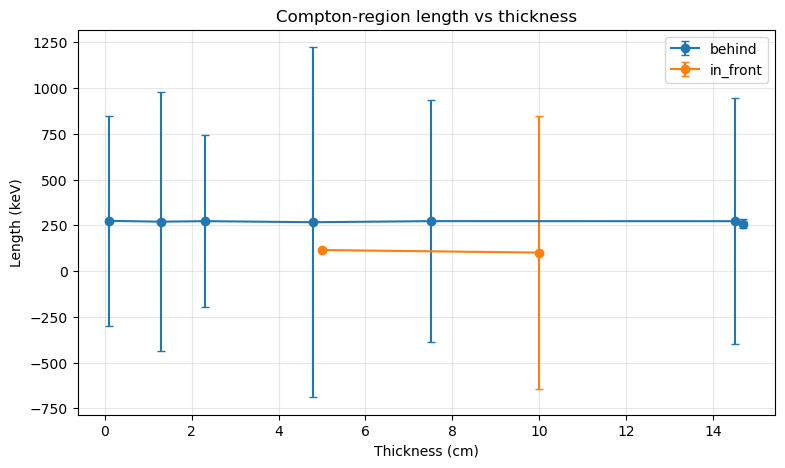

In [13]:
# -----------------------------
# ANALYSIS 3: COMPTON-CONTINUUM SHAPE
# -----------------------------
grouped_error_plot(
    thickness_df,
    xcol="thickness_cm",
    ycol="compton_region_slope_counts_per_s_per_keV__backscatter_peak",
    yerrcol="compton_region_slope_err_per_keV__backscatter_peak",
    groupcol="geometry_position",
    title="Compton-region slope vs thickness",
    xlabel="Thickness (cm)",
    ylabel="Slope ((counts/s)/keV)",
)

grouped_error_plot(
    thickness_df,
    xcol="thickness_cm",
    ycol="compton_region_length_keV__backscatter_peak",
    yerrcol="compton_region_length_keV_err__backscatter_peak",
    groupcol="geometry_position",
    title="Compton-region length vs thickness",
    xlabel="Thickness (cm)",
    ylabel="Length (keV)",
)


,file,day,center_keV__backscatter_peak,center_keV_err__backscatter_peak,center_keV__compton_edge,center_keV_err__compton_edge,photopeak_center_keV,photopeak_center_keV_err
3,calibration/feb_24/preamp_0/Cs_22.1C_preamp0_f...,feb24,188.580676,12.536595,438.286531,31.391404,661.715806,3.114094
4,cs gain setting/Cs_possible_calcurve_feb_24.csv,feb24,186.474638,7.165633,437.984722,33.367486,NaN,NaN
2,calibration/daily/Cs_22.4C_preamp0_feb26.csv,feb26,184.280719,23.944862,441.016555,112.598813,658.982364,10.719534
6,data/feb_26/cs137/Cs_22.4C_feb26_run1.csv,feb26,185.851736,11.553169,435.289575,22.826571,659.073403,10.720211
1,calibration/daily/Cs_22.0C_preamp0_mar3.csv,mar3,199.181625,18.493334,438.860025,45.841312,662.341343,14.816546
7,data/mar_3/cs137/Cs_22.5C_mar3_run1.csv,mar3,199.603798,16.875137,461.742007,2201.825837,661.596694,14.816128
0,calibration/daily/Cs_21.9C_preamp0_mar5.csv,mar5,196.809441,11.399721,435.357846,23.326485,661.693837,3.112571
8,data/mar_5/cs137/Cs_21.9C_mar5_run1.csv,mar5,195.781512,14.256921,463.491952,996.058251,661.739715,3.114267
5,cs gain setting/Cs_trial_feb_19.csv,None,148.812316,2.751885,332.621867,10.077677,NaN,NaN


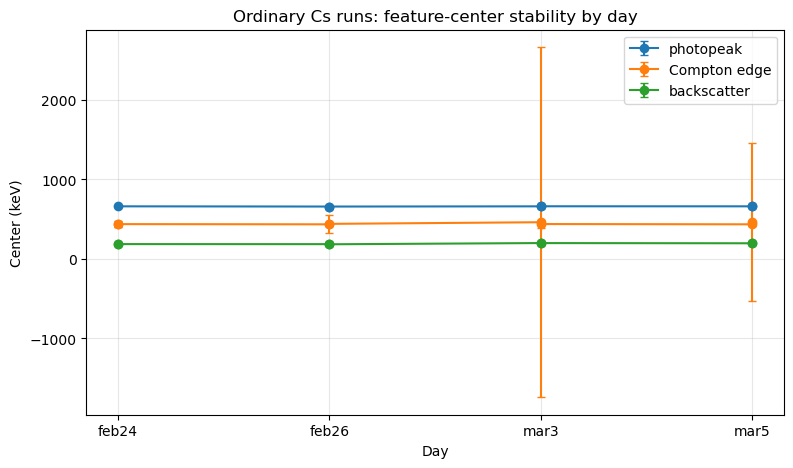

In [14]:
# -----------------------------
# ANALYSIS 4: ORDINARY CS STABILITY CONTROLS
# -----------------------------
standard_df = analysis_df[analysis_df["geometry_position"] == "standard"].copy()
display(standard_df[[
    "file",
    "day",
    "center_keV__backscatter_peak",
    "center_keV_err__backscatter_peak",
    "center_keV__compton_edge",
    "center_keV_err__compton_edge",
    "photopeak_center_keV",
    "photopeak_center_keV_err",
]].sort_values("day", na_position="last"))

day_stability_plot(
    standard_df,
    ycols=[
        "photopeak_center_keV",
        "center_keV__compton_edge",
        "center_keV__backscatter_peak",
    ],
    yerrcols=[
        "photopeak_center_keV_err",
        "center_keV_err__compton_edge",
        "center_keV_err__backscatter_peak",
    ],
    labels=[
        "photopeak",
        "Compton edge",
        "backscatter",
    ],
    title="Ordinary Cs runs: feature-center stability by day",
    ylabel="Center (keV)",
)


In [15]:
# -----------------------------
# OPTIONAL WINDOW-INTEGRATION ANALYSIS
# -----------------------------
def _extract_first_number(text):
    if text is None:
        return None
    m = re.search(r"[-+]?\d*\.?\d+", str(text))
    if m is None:
        return None
    try:
        return float(m.group())
    except Exception:
        return None

def load_spectrum(csv_path):
    with open(csv_path, "r", encoding="utf-8", errors="replace") as f:
        lines = f.readlines()

    metadata = {}
    data_start_idx = None

    for i, line in enumerate(lines):
        stripped = line.strip()

        if stripped == "Channel Data:":
            data_start_idx = i + 1
            break

        if "Elapsed Real Time:" in stripped:
            value = stripped.split("Elapsed Real Time:", 1)[1]
            value = value.split(",", 1)[1].strip() if "," in value else value.strip()
            metadata["Elapsed Real Time"] = value

    if data_start_idx is None:
        raise RuntimeError(f"Could not locate channel data block in {csv_path}")

    if data_start_idx < len(lines):
        header_line = lines[data_start_idx].strip().lower()
        if header_line.startswith("channel"):
            data_start_idx += 1

    rows = []
    for line in lines[data_start_idx:]:
        stripped = line.strip()
        if not stripped:
            continue
        parts = [p.strip() for p in stripped.split(",")]
        if len(parts) < 3:
            continue
        try:
            rows.append((float(parts[0]), float(parts[2])))
        except ValueError:
            continue

    if len(rows) == 0:
        raise RuntimeError(f"No numeric data in {csv_path}")

    arr = np.asarray(rows, dtype=float)
    x = arr[:, 0]
    y = arr[:, 1]

    rt = metadata.get("Elapsed Real Time", None)
    live_time_s = _extract_first_number(rt)
    return x, y, live_time_s

def counts_to_rate(counts, live_time_s):
    return np.asarray(counts, dtype=float) / float(live_time_s)

def background_subtracted_rate(sample_relpath, background_path=BACKGROUND_FILE):
    sample_path = ROOT / sample_relpath

    x_s, y_s, t_s = load_spectrum(sample_path)
    x_b, y_b, t_b = load_spectrum(background_path)

    rate_s = counts_to_rate(y_s, t_s)
    rate_b = counts_to_rate(y_b, t_b)

    # Robust fix for the previous grid-mismatch error:
    if len(x_s) != len(x_b) or not np.allclose(x_s, x_b):
        rate_b = np.interp(x_s, x_b, rate_b, left=rate_b[0], right=rate_b[-1])

    return x_s, rate_s - rate_b

def integrate_window(x, y, xmin, xmax):
    mask = (x >= xmin) & (x <= xmax)
    if not np.any(mask):
        return np.nan
    return np.trapz(y[mask], x[mask])

window_rows = []
for _, row in analysis_df.iterrows():
    file = row["file"]
    back = row["center_ADC__backscatter_peak"]
    edge = row["center_ADC__compton_edge"]

    if not (np.isfinite(back) and np.isfinite(edge) and edge > back):
        continue

    x, y = background_subtracted_rate(file)
    total = integrate_window(x, y, x.min(), x.max())
    if not np.isfinite(total) or total == 0:
        continue

    low = integrate_window(x, y, 0, back - 0.5 * (edge - back))
    around_back = integrate_window(x, y, back - 15, back + 15)
    continuum = integrate_window(x, y, back, edge)
    above_edge = integrate_window(x, y, edge, min(edge + 150, x.max()))

    window_rows.append({
        "file": file,
        "low_fraction": low / total if np.isfinite(low) else np.nan,
        "backscatter_window_fraction": around_back / total if np.isfinite(around_back) else np.nan,
        "continuum_fraction": continuum / total if np.isfinite(continuum) else np.nan,
        "above_edge_fraction": above_edge / total if np.isfinite(above_edge) else np.nan,
    })

window_df = pd.DataFrame(window_rows)
window_analysis_df = analysis_df.merge(window_df, on="file", how="left")
display(window_analysis_df.head(20))


/tmp/ipykernel_7404/1265362244.py:88: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y[mask], x[mask])


,file,amplitude_counts_per_s__backscatter_peak,amplitude_counts_per_s__compton_edge,amplitude_counts_per_s_err__backscatter_peak,amplitude_counts_per_s_err__compton_edge,center_ADC__backscatter_peak,center_ADC__compton_edge,center_ADC_err__backscatter_peak,center_ADC_err__compton_edge,center_keV__backscatter_peak,center_keV__compton_edge,center_keV_err__backscatter_peak,center_keV_err__compton_edge,compton_region_length_ADC__backscatter_peak,compton_region_length_ADC__compton_edge,compton_region_length_ADC_err__backscatter_peak,compton_region_length_ADC_err__compton_edge,compton_region_length_keV__backscatter_peak,compton_region_length_keV__compton_edge,compton_region_length_keV_err__backscatter_peak,compton_region_length_keV_err__compton_edge,compton_region_redchi2__backscatter_peak,compton_region_redchi2__compton_edge,compton_region_slope_counts_per_s_per_ADC__backscatter_peak,compton_region_slope_counts_per_s_per_ADC__compton_edge,compton_region_slope_counts_per_s_per_keV__backscatter_peak,compton_region_slope_counts_per_s_per_keV__compton_edge,compton_region_slope_err_per_keV__backscatter_peak,compton_region_slope_err_per_keV__compton_edge,fit_redchi2__backscatter_peak,fit_redchi2__compton_edge,gaussian_area_counts__backscatter_peak,gaussian_area_counts__compton_edge,gaussian_area_counts_err__backscatter_peak,gaussian_area_counts_err__compton_edge,sigma_ADC__backscatter_peak,sigma_ADC__compton_edge,sigma_ADC_err__backscatter_peak,sigma_ADC_err__compton_edge,sigma_keV__backscatter_peak,sigma_keV__compton_edge,sigma_keV_err__backscatter_peak,sigma_keV_err__compton_edge,geometry_position,material,run_role,thickness_cm,pmt_distance_cm,source_to_pmt_cm,day,preamp,photopeak_center_ADC,photopeak_center_ADC_err,photopeak_center_keV,photopeak_center_keV_err,photopeak_sigma_ADC,photopeak_sigma_ADC_err,photopeak_sigma_keV,photopeak_sigma_keV_err,photopeak_amplitude_counts_per_s,photopeak_amplitude_counts_per_s_err,photopeak_area_counts,backscatter_to_photopeak_area_ratio,backscatter_to_photopeak_area_ratio_err,backscatter_to_photopeak_amp_ratio,backscatter_to_photopeak_amp_ratio_err,edge_minus_backscatter_keV,edge_minus_backscatter_keV_err,photopeak_minus_edge_keV,photopeak_minus_edge_keV_err,low_fraction,backscatter_window_fraction,continuum_fraction,above_edge_fraction
0,calibration/daily/Cs_21.9C_preamp0_mar5.csv,3.383306,0.334910,4.015823,0.928165,152.345500,333.397008,8.495143,17.597236,196.809441,435.357846,11.399721,23.326485,181.051508,181.051508,19.540475,19.540475,238.548405,238.548405,25.963023,25.963023,0.072381,0.072381,-0.012667,-0.012667,-0.009614,-0.009614,0.000654,0.000654,0.002118,0.061216,96.774870,4.648408,154.543275,22.220366,11.411201,5.537148,12.191034,21.566336,15.035079,7.295591,16.062652,28.415213,standard,none,measurement,NaN,NaN,NaN,mar5,0,505.179638,0.180231,661.693837,3.112571,14.941343,0.204523,19.686296,0.278190,38.228217,0.406552,1431.738174,0.067593,0.107956,0.088503,0.105053,238.548405,25.963023,226.335991,23.533232,0.056769,0.066834,0.269474,0.101576
1,calibration/daily/Cs_22.0C_preamp0_mar3.csv,2.477301,0.210314,4.105459,1.453718,154.145921,336.055063,8.569695,32.952023,199.181625,438.860025,18.493334,45.841312,181.909142,181.909142,34.048135,34.048135,239.678400,239.678400,49.431056,49.431056,0.069304,0.069304,-0.010736,-0.010736,-0.008148,-0.008148,0.000553,0.000553,0.001282,0.001279,66.074651,2.846126,155.003545,33.394145,10.640603,5.398797,17.667129,51.186167,14.019761,7.113303,23.277768,67.441468,standard,none,measurement,NaN,NaN,NaN,mar3,0,505.671076,0.183272,662.341343,14.816546,14.848871,0.208210,19.564457,0.282794,28.570616,0.309751,1063.415433,0.062134,0.145773,0.086708,0.143698,239.678400,49.431056,223.481318,48.176300,0.057112,0.071552,0.272802,0.108577
2,calibration/daily/Cs_22.4C_preamp0_feb26.csv,4.735009,2.583595,21.661652,37.318277,142.836554,337.691808,16.339436,85.081398,184.280719,441.016555,23.944862,112.598813,194.855254,194.855254,86.636145,86.636145,256.735836,256.735836,11

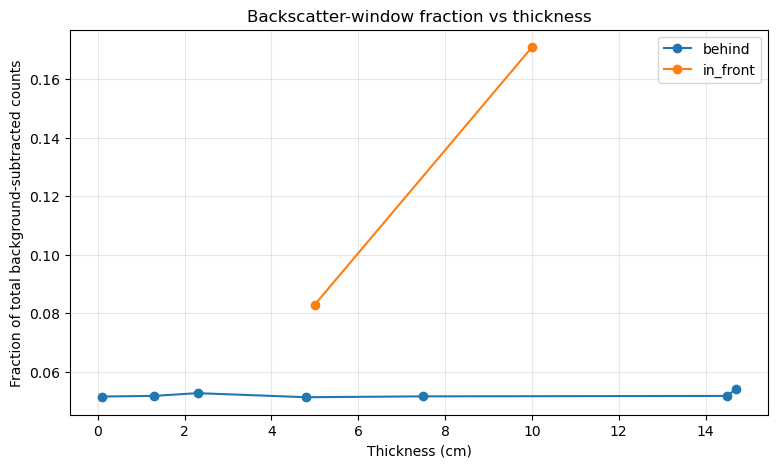

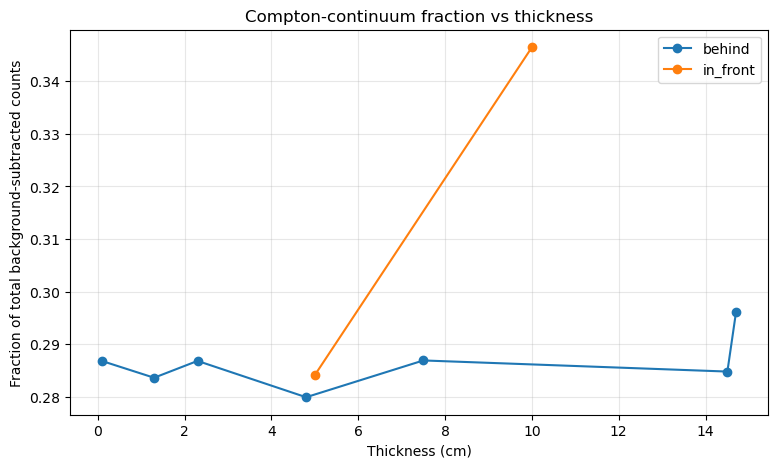

In [16]:
# -----------------------------
# EXAMPLE WINDOW-FRACTION PLOTS
# -----------------------------
if "window_analysis_df" in globals():
    window_thickness_df = window_analysis_df[
        window_analysis_df["geometry_position"].isin(["behind", "in_front"])
    ].copy()

    grouped_error_plot(
        window_thickness_df,
        xcol="thickness_cm",
        ycol="backscatter_window_fraction",
        groupcol="geometry_position",
        title="Backscatter-window fraction vs thickness",
        xlabel="Thickness (cm)",
        ylabel="Fraction of total background-subtracted counts",
    )

    grouped_error_plot(
        window_thickness_df,
        xcol="thickness_cm",
        ycol="continuum_fraction",
        groupcol="geometry_position",
        title="Compton-continuum fraction vs thickness",
        xlabel="Thickness (cm)",
        ylabel="Fraction of total background-subtracted counts",
    )
